<a href="https://colab.research.google.com/github/arpitarumma/ECOPERCEPT/blob/main/CONSMERPERCP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#*******************************************************************PREPROCESSING*******************************************************
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from sklearn.impute import KNNImputer

# Load Excel file
file_path = "/content/Consumer_Perceptions.xlsx"
df = pd.read_excel(file_path)

# Make a copy
df_cleaned = df.copy()

# Try converting numeric-looking columns
for col in df_cleaned.columns:
    df_cleaned[col] = pd.to_numeric(df_cleaned[col], errors="ignore")

#  Handle missing values
# Step 1: Categorical -fill using group-based mode
cat_cols = df_cleaned.select_dtypes(include='object').columns
num_cols = df_cleaned.select_dtypes(include='number').columns

for col in cat_cols:
    # try grouping by 'State' or 'Age group' if present
    if "State" in df_cleaned.columns:
        df_cleaned[col] = df_cleaned.groupby("State")[col].transform(lambda x: x.fillna(x.mode()[0] if not x.mode().empty else "Unknown"))
    elif "What is your age group?" in df_cleaned.columns:
        df_cleaned[col] = df_cleaned.groupby("What is your age group?")[col].transform(lambda x: x.fillna(x.mode()[0] if not x.mode().empty else "Unknown"))
    else:
        # fallback: global mode
        mode_val = df_cleaned[col].mode()[0]
        df_cleaned[col].fillna(mode_val, inplace=True)

# Step 2: Numerical - use KNN imputer
if len(num_cols) > 0:
    imputer = KNNImputer(n_neighbors=5)
    df_cleaned[num_cols] = imputer.fit_transform(df_cleaned[num_cols])
# Keep original categories, just handle missing values + numeric scaling
for col in df_cleaned.columns:
    if df_cleaned[col].dtype == 'object':
        mode_val = df_cleaned[col].mode()[0]
        df_cleaned[col].fillna(mode_val, inplace=True)
    else:
        df_cleaned[col].fillna(df_cleaned[col].median(), inplace=True)

# Normalize numeric columns only
scaler = MinMaxScaler()
num_cols = df_cleaned.select_dtypes(include='number').columns
if len(num_cols) > 0:
    df_cleaned[num_cols] = scaler.fit_transform(df_cleaned[num_cols])

# Save with original categories intact
df_cleaned.to_excel("Processed_EcoFriendly_Data_OriginalCats.xlsx", index=False)



/tmp/ipython-input-2544570897.py:15: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df_cleaned[col] = pd.to_numeric(df_cleaned[col], errors="ignore")
/tmp/ipython-input-2544570897.py:41: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_cleaned[col].fillna(mode_val, inplace=True)


Shape of dataset: (508, 21)

Column types:
 Timestamp                                                                                         object
Name                                                                                              object
What is your age group?                                                                           object
What is your gender?                                                                              object
What is your occupation?                                                                          object
What is your monthly income range?                                                                object
How familiar are you with the term “eco-friendly products”?                                       object
How important is sustainability in your purchasing decisions?                                     object
What motivates you to consider eco-friendly products?                                             object
Have you ev

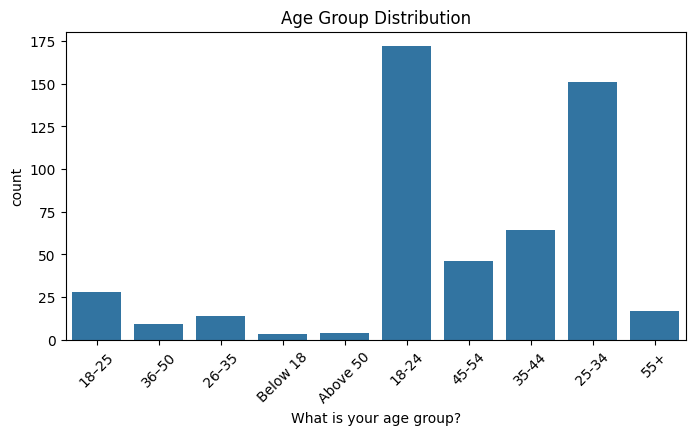

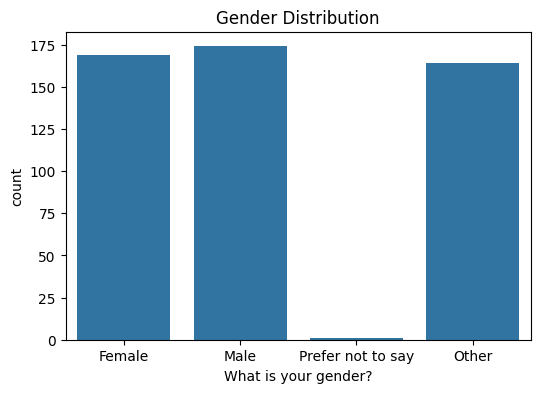

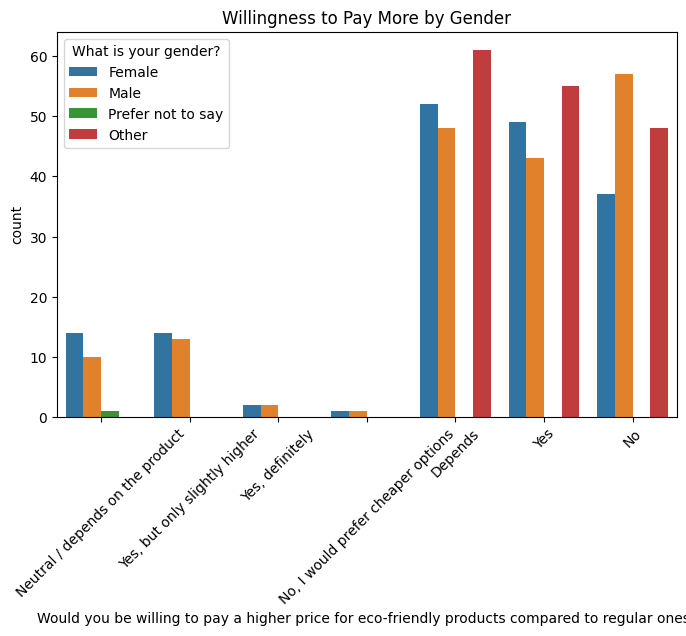


Most common words in suggestions: [('Better', 128), ('designs', 128), ('Awareness', 118), ('campaigns', 117), ('Lower', 116), ('prices', 116), ('More', 101), ('availability', 98), ('and', 12), ('the', 9), ('more', 7), ('to', 7), ('it', 5), ('certified', 5), ('Good', 5), ('benefits', 5), ('should', 5), ('is', 4), ('Unknown', 4), ('product', 4)]


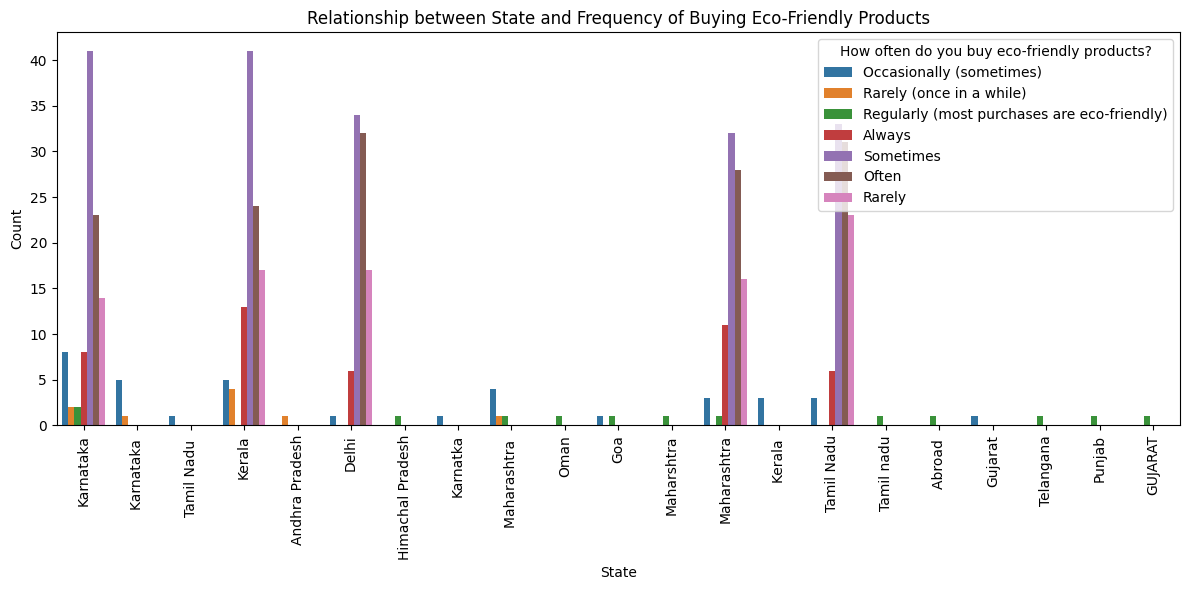

In [ ]:
#************************************************************EXPLORATORY DATA ANAYSIS***************************************
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

#  Load preprocessed file
file_path = "/content/drive/MyDrive/CONSUMERPERCEPION/Processed_EcoFriendly_Data_OriginalCats.xlsx"
df = pd.read_excel(file_path)

# Strip whitespace from column names
df.columns = df.columns.str.strip()

# 1. Basic Info
print("Shape of dataset:", df.shape)
print("\nColumn types:\n", df.dtypes)
print("\nSummary stats (numerical):\n", df.describe())
print("\nMissing values:\n", df.isna().sum())

#  2. Univariate Analysis
# Example: Age group distribution
plt.figure(figsize=(8,4))
sns.countplot(data=df, x="What is your age group?")
plt.xticks(rotation=45)
plt.title("Age Group Distribution")
plt.show()

# Example: Gender distribution
plt.figure(figsize=(6,4))
sns.countplot(data=df, x="What is your gender?")
plt.title("Gender Distribution")
plt.show()

# 3. Bivariate Analysis
# Example: Gender vs Willingness to Pay More
plt.figure(figsize=(8,5))
sns.countplot(data=df, x="Would you be willing to pay a higher price for eco-friendly products compared to regular ones?", hue="What is your gender?")
plt.xticks(rotation=45)
plt.title("Willingness to Pay More by Gender")
plt.show()

# Example: Age vs Familiarity (Plotly interactive)
fig = px.histogram(df, x="What is your age group?", color="How familiar are you with the term “eco-friendly products”?")
fig.update_layout(title="Age Group vs Familiarity with Eco-Friendly Products")
fig.show()

#  4. Correlation Analysis (Numerical only)
num_cols = df.select_dtypes(include='number').columns
if len(num_cols) > 1:
    plt.figure(figsize=(10,6))
    sns.heatmap(df[num_cols].corr(), annot=True, cmap="coolwarm", fmt=".2f")
    plt.title("Correlation Heatmap (Numerical Features)")
    plt.show()

# 5. Example Word Frequency
from collections import Counter

if "Any suggestions for brands to make eco-friendly products more attractive to you?" in df.columns:
    all_text = " ".join(df["Any suggestions for brands to make eco-friendly products more attractive to you?"].dropna().astype(str))
    words = Counter(all_text.split())
    print("\nMost common words in suggestions:", words.most_common(20))

plt.figure(figsize=(12, 6))
sns.countplot(data=df, x='State', hue='How often do you buy eco-friendly products?')
plt.xticks(rotation=90)
plt.title('Relationship between State and Frequency of Buying Eco-Friendly Products')
plt.xlabel('State')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

In [ ]:
#*************************Algorithm Accuracy Comparison************************************
%pip install catboost
import pandas as pd
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
from catboost import CatBoostClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# ✅ Load preprocessed dataset (from previous step)
df_model = df_cleaned.copy()

# Strip whitespace from column names
df_model.columns = df_model.columns.str.strip()

# Drop non-numeric columns that are not suitable for modeling
cols_to_drop = ['Timestamp', 'Name', 'Any suggestions for brands to make eco-friendly products more attractive to you?']
df_model = df_model.drop(columns=cols_to_drop)

# Example target (you can change to:
# "Have you ever purchased...", "Would you pay higher price", etc.)
target_col = "Have you ever purchased an eco-friendly/sustainable product?"
X = df_model.drop(columns=[target_col])
y = df_model[target_col]

# Convert categorical columns to dummy variables for modeling
X = pd.get_dummies(X, drop_first=True)

# Sanitize column names for tree-based models (XGBoost, LightGBM, CatBoost)
X.columns = X.columns.str.replace('[', '_').str.replace(']', '_').str.replace('<', '_').str.replace('=', '_').str.replace(',', '_').str.replace(' ', '_')


# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Convert target variable to numeric if it's not already
if y.dtype == 'object':
    y = y.astype('category').cat.codes
    y_train = y_train.astype('category').cat.codes
    y_test = y_test.astype('category').cat.codes


# Define algorithms to test
models = {
    "Logistic Regression": LogisticRegression(max_iter=500),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric="logloss"),
    "LightGBM": LGBMClassifier(),
    "CatBoost": CatBoostClassifier(verbose=0)
}

# Evaluate models
results = []
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average="weighted")
    results.append([name, acc, f1])

# Show results
results_df = pd.DataFrame(results, columns=["Model", "Accuracy", "F1 Score"])
print(results_df.sort_values(by="Accuracy", ascending=False))

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 7.9 MB/s eta 0:00:00


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning:

[07:05:11] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.




[LightGBM] [Info] Number of positive: 433, number of negative: 373
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000293 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 222
[LightGBM] [Info] Number of data points in the train set: 806, number of used features: 111
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.537221 -> initscore=0.149159
[LightGBM] [Info] Start training from score 0.149159
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


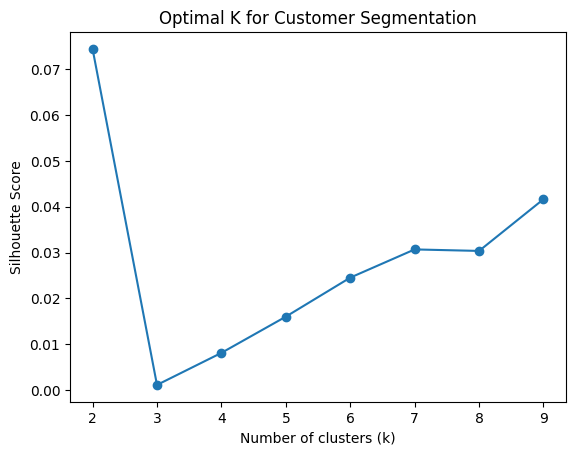

✅ Segmentation complete → Best K = 2
Do you prefer to purchase eco friendly products online or offline?                                                                                                                                                                                                                                                                                                                                                               Both  \
Cluster What is your age group? What is your gender? What is your occupation? What is your monthly income range? How familiar are you with the term “eco-friendl... How important is sustainability in your purchas... How often do you buy eco-friendly products? Do you trust brands when they label products as... Would you be willing to pay a higher price for ... How likely are you to recommend eco-friendly pr...             
0       18-24                   Female               Business                 <20,000                            

In [ ]:
#*************************************Segmentation (Clustering: Demographics + Behavior)*******************************
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import pandas as pd

# Select demographic + behavior features
cluster_features = [
    "What is your age group?",
    "  What is your gender?  ",
    "What is your occupation?",
    "What is your monthly income range?",
    "  How familiar are you with the term “eco-friendly products”?  ",
    "How important is sustainability in your purchasing decisions?",
    "How often do you buy eco-friendly products?",
    "Do you trust brands when they label products as “eco-friendly” or “sustainable”?",
    "Would you be willing to pay a higher price for eco-friendly products compared to regular ones?",
    "How likely are you to recommend eco-friendly products to your friends/family?",
    "Do you prefer to purchase eco friendly products online or offline?",
]

# Strip whitespace from column names in the list
cluster_features = [col.strip() for col in cluster_features]

X_cluster = df_cleaned[cluster_features]

# Convert categorical features to numerical using one-hot encoding
X_cluster_encoded = pd.get_dummies(X_cluster, drop_first=True)


# Scale for KMeans
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster_encoded)

# Find optimal K using silhouette
scores = []
for k in range(2, 10):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10) # Added n_init to suppress warning
    labels = kmeans.fit_predict(X_scaled)
    scores.append((k, silhouette_score(X_scaled, labels)))

# Plot Silhouette scores
plt.plot([k for k, _ in scores], [s for _, s in scores], marker='o')
plt.xlabel("Number of clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Optimal K for Customer Segmentation")
plt.show()

# Fit best K
best_k = max(scores, key=lambda x: x[1])[0]
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10) # Added n_init
df_cleaned["Cluster"] = kmeans.fit_predict(X_scaled)

print(f"✅ Segmentation complete → Best K = {best_k}")
# To interpret clusters, we can look at the mean of the original (or encoded) features per cluster
print(df_cleaned.groupby("Cluster")[cluster_features].value_counts(normalize=True).unstack())

In [ ]:
#*************************************Classification (Predict Purchase Intention / Willingness to Pay)**********************
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import pandas as pd

def evaluate_classification(target_col):
    # Define free text columns to drop
    free_text_cols = ['Timestamp', 'Name', 'Any suggestions for brands to make eco-friendly products more attractive to you?']

    # Use df_cleaned instead of df_clean
    df_model = df_cleaned.copy()

    # Strip whitespace from column names
    df_model.columns = df_model.columns.str.strip()

    # Drop non-numeric columns that are not suitable for modeling
    cols_to_drop = [target_col] + free_text_cols
    df_model = df_model.drop(columns=cols_to_drop)

    X = df_model
    y = df_cleaned[target_col] # Use target column from original df_cleaned

    # Convert categorical columns to dummy variables for modeling
    X = pd.get_dummies(X, drop_first=True)

    # Sanitize column names for tree-based models (XGBoost, LightGBM, CatBoost)
    X.columns = X.columns.str.replace('[', '_').str.replace(']', '_').str.replace('<', '_').str.replace('=', '_').str.replace(',', '_').str.replace(' ', '_')


    # Split dataset
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    # Convert target variable to numeric if it's not already
    if y_train.dtype == 'object':
        y_train = y_train.astype('category').cat.codes
        y_test = y_test.astype('category').cat.codes


    models = {
        "Logistic Regression": LogisticRegression(max_iter=500),
        "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42),
        "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric="logloss"),
        "CatBoost": CatBoostClassifier(verbose=0)
    }

    results = []
    for name, model in models.items():
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        acc = accuracy_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred, average="weighted")
        results.append([name, acc, f1])

    return pd.DataFrame(results, columns=["Model", "Accuracy", "F1 Score"]).sort_values(by="Accuracy", ascending=False)

# Example 1: Predict purchase intention
print("🔹 Predicting Purchase Intention")
print(evaluate_classification("Have you ever purchased an eco-friendly/sustainable product?"))

# Example 2: Predict willingness to pay
print("🔹 Predicting Willingness to Pay")
print(evaluate_classification("Would you be willing to pay a higher price for eco-friendly products compared to regular ones?"))

🔹 Predicting Purchase Intention
                 Model  Accuracy  F1 Score
3             CatBoost  0.633663  0.633012
2              XGBoost  0.618812  0.618934
1        Random Forest  0.584158  0.584158
0  Logistic Regression  0.554455  0.554718
🔹 Predicting Willingness to Pay
                 Model  Accuracy  F1 Score
3             CatBoost  0.277228  0.276667
2              XGBoost  0.262376  0.262392
0  Logistic Regression  0.232673  0.236974
1        Random Forest  0.212871  0.208502


In [ ]:
#**********************Text Analysis (TF-IDF Embeddings: Motivations, Barriers, Suggestions)******************************************
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import NMF
import pandas as pd # Import pandas

# Pick one free-text column (can loop through)
text_col = "What motivates you to consider eco-friendly products?"

# Strip whitespace from column name variable
text_col = text_col.strip()

# Strip whitespace from column names of df
df.columns = df.columns.str.strip()

# Ensure column names in df_cleaned are also stripped
df_cleaned.columns = df_cleaned.columns.str.strip()

# Handle missing values in the selected text column in df_cleaned
df_cleaned[text_col].fillna("", inplace=True)

# TF-IDF
tfidf = TfidfVectorizer(stop_words="english", max_features=500)
X_tfidf = tfidf.fit_transform(df_cleaned[text_col])

# Topic modeling (NMF)
nmf = NMF(n_components=5, random_state=42)
W = nmf.fit_transform(X_tfidf)
H = nmf.components_

# Show top words per topic
feature_names = tfidf.get_feature_names_out()
for topic_idx, topic in enumerate(H):
    top_words = [feature_names[i] for i in topic.argsort()[:-8:-1]]
    print(f"Topic {topic_idx+1}: {', '.join(top_words)}")

# Assign dominant topic to each response
df_cleaned[f"{text_col}_Topic"] = W.argmax(axis=1)
print(df_cleaned[[text_col, f"{text_col}_Topic"]].head())

Topic 1: environmental, concern, social, run, reputation, savings, safety
Topic 2: social, influence, peer, image, run, safety, savings
Topic 3: health, benefits, safety, run, reputation, social, savings
Topic 4: reputation, brand, savings, safety, run, peer, social
Topic 5: savings, long, run, cost, safety, reputation, social
  What motivates you to consider eco-friendly products?  \
0                                  Health and safety      
1                                  Health and safety      
2                              Environmental concern      
3                              Environmental concern      
4                                  Health and safety      

   What motivates you to consider eco-friendly products?_Topic  
0                                                  2            
1                                                  2            
2                                                  0            
3                                                  0    

/tmp/ipython-input-3915267727.py:19: FutureWarning:

A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.





In [ ]:
#*********************************ANOVA STATISTICS*****************************
from scipy.stats import f_oneway
import pandas as pd

# Define columns
trust_col = "Do you trust brands when they label products as “eco-friendly” or “sustainable”?"
state_col = "State"

# Convert trust responses to numerical labels
df_cleaned[trust_col + '_encoded'] = df_cleaned[trust_col].astype('category').cat.codes

# Group encoded trust responses by state
groups = [group[trust_col + '_encoded'].values for name, group in df_cleaned.groupby(state_col)]

# Run one-way ANOVA
# Filter out groups with only one sample
groups = [group for group in groups if len(group) > 1]

if len(groups) > 1:
    f_stat, p_val = f_oneway(*groups)

    print("ANOVA F-statistic:", f_stat)
    print("p-value:", p_val)

    if p_val < 0.05:
        print("✅ Significant difference in eco-trust across states")
    else:
        print("❌ No significant difference in eco-trust across states")
else:
    print("Not enough groups with more than one sample to perform ANOVA.")

ANOVA F-statistic: 3.331736693678502
p-value: 1.1393715861558747e-06
✅ Significant difference in eco-trust across states
